In [1]:
import os
import sys
from pathlib import Path

# Make `src` importable regardless of notebook working directory.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd

from src.paths import get_data_dir

DATA_DIR = Path(get_data_dir())
PLOTS_DIR = Path("eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

FILES = [
    "MTeams.csv",
    "WTeams.csv",
    "MNCAATourneyCompactResults.csv",
    "WNCAATourneyCompactResults.csv",
    "MNCAATourneySeeds.csv",
    "WNCAATourneySeeds.csv",
    "MRegularSeasonCompactResults.csv",
    "WRegularSeasonCompactResults.csv",
    "MRegularSeasonDetailedResults.csv",
    "WRegularSeasonDetailedResults.csv",
    "MMasseyOrdinals.csv",
    "SampleSubmissionStage1.csv",
    "SampleSubmissionStage2.csv",
]

print("Using DATA_DIR:", str(DATA_DIR))
print("Saving plots to:", str(PLOTS_DIR))

def _season_range(df: pd.DataFrame) -> tuple[int | None, int | None]:
    if "Season" not in df.columns:
        return (None, None)
    s = pd.to_numeric(df["Season"], errors="coerce").dropna().astype(int)
    if s.empty:
        return (None, None)
    return (int(s.min()), int(s.max()))

rows = []
for fname in FILES:
    path = DATA_DIR / fname
    if not path.exists():
        print(f"[MISSING] {fname} (expected at {path})")
        continue

    df = pd.read_csv(path)
    null_rate = float(df.isna().mean().mean()) if len(df.columns) else 0.0
    smin, smax = _season_range(df)

    flagged = "YES" if null_rate > 0.01 else "no"
    print("=" * 80)
    print(fname)
    print("Rows:", len(df))
    print("Columns:", list(df.columns))
    print(f"Null rate (overall): {null_rate:.4%}  |  >1% nulls? {flagged}")
    print("Season range:", (smin, smax))

    rows.append(
        {
            "file": fname,
            "rows": int(len(df)),
            "n_cols": int(df.shape[1]),
            "null_rate": null_rate,
            "season_min": smin,
            "season_max": smax,
            "flag_gt_1pct_nulls": flagged,
        }
    )

inventory = pd.DataFrame(rows).sort_values(["flag_gt_1pct_nulls", "file"], ascending=[False, True])
print("\nInventory summary:")
print(inventory.to_string(index=False))

Using DATA_DIR: C:\Users\charl\Documents\Projects\march-machine-learning-mania-2026\data
Saving plots to: eda_plots
MTeams.csv
Rows: 381
Columns: ['TeamID', 'TeamName', 'FirstD1Season', 'LastD1Season']
Null rate (overall): 0.0000%  |  >1% nulls? no
Season range: (None, None)
WTeams.csv
Rows: 379
Columns: ['TeamID', 'TeamName']
Null rate (overall): 0.0000%  |  >1% nulls? no
Season range: (None, None)
MNCAATourneyCompactResults.csv
Rows: 2585
Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT']
Null rate (overall): 0.0000%  |  >1% nulls? no
Season range: (1985, 2025)
WNCAATourneyCompactResults.csv
Rows: 1717
Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT']
Null rate (overall): 0.0000%  |  >1% nulls? no
Season range: (1998, 2025)
MNCAATourneySeeds.csv
Rows: 2694
Columns: ['Season', 'Seed', 'TeamID']
Null rate (overall): 0.0000%  |  >1% nulls? no
Season range: (1985, 2026)
WNCAATourneySeeds.csv
Rows: 1812
Columns: 

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


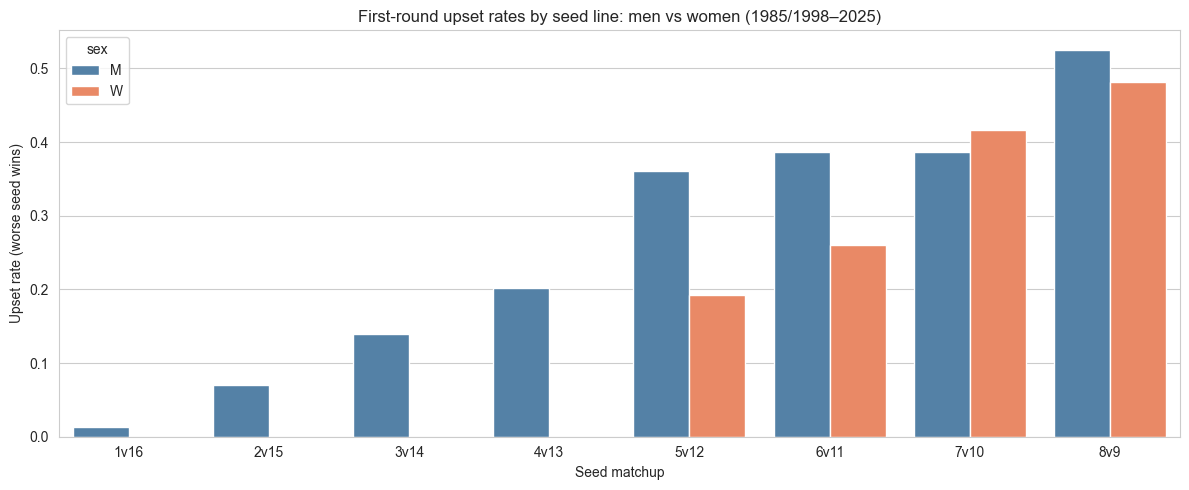

Saved: eda_plots\cell2_upset_rates_by_seed.png


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.paths import get_data_dir

DATA_DIR = Path(get_data_dir())
PLOTS_DIR = Path("eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

def _seed_num(seed_str: str) -> int | None:
    # Handles "W01", "X16a", etc.
    if not isinstance(seed_str, str):
        return None
    digits = "".join([c for c in seed_str if c.isdigit()])
    if not digits:
        return None
    return int(digits[:2]) if len(digits) >= 2 else int(digits)

def _load_seed_map(path: Path) -> pd.DataFrame:
    seeds = pd.read_csv(path)[["Season", "TeamID", "Seed"]].copy()
    seeds["Season"] = seeds["Season"].astype(int)
    seeds["TeamID"] = seeds["TeamID"].astype(int)
    seeds["SeedNum"] = seeds["Seed"].astype(str).map(_seed_num)
    return seeds[["Season", "TeamID", "SeedNum"]]

def _first_round(df: pd.DataFrame, sex: str) -> pd.DataFrame:
    # Prompt rule: men DayNum 136-137; women equivalent not explicitly given.
    # We’ll use the same DayNum window for women to match the prompt’s intent.
    d = df.copy()
    d["Season"] = d["Season"].astype(int)
    d["DayNum"] = d["DayNum"].astype(int)
    d = d[d["DayNum"].between(136, 137, inclusive="both")]
    d["sex"] = sex
    return d

def _upset_rates_by_seed_line(
    tourney_compact: pd.DataFrame,
    seeds: pd.DataFrame,
    sex: str,
) -> pd.DataFrame:
    g = _first_round(tourney_compact, sex)

    g = g.merge(
        seeds.rename(columns={"TeamID": "WTeamID", "SeedNum": "WSeed"}),
        on=["Season", "WTeamID"],
        how="left",
    ).merge(
        seeds.rename(columns={"TeamID": "LTeamID", "SeedNum": "LSeed"}),
        on=["Season", "LTeamID"],
        how="left",
    )

    g = g.dropna(subset=["WSeed", "LSeed"]).copy()
    g["WSeed"] = g["WSeed"].astype(int)
    g["LSeed"] = g["LSeed"].astype(int)

    # First-round matchups are 1v16..8v9; use normalized ordering.
    g["seed_low"] = np.minimum(g["WSeed"], g["LSeed"])
    g["seed_high"] = np.maximum(g["WSeed"], g["LSeed"])

    valid = {(1, 16), (2, 15), (3, 14), (4, 13), (5, 12), (6, 11), (7, 10), (8, 9)}
    g = g[g.apply(lambda r: (int(r["seed_low"]), int(r["seed_high"])) in valid, axis=1)].copy()

    # Upset = higher seed number wins (i.e., worse seed wins).
    g["upset"] = ((g["WSeed"] > g["LSeed"])).astype(int)

    out = (
        g.groupby(["seed_low", "seed_high"], as_index=False)
        .agg(upset_rate=("upset", "mean"), n_games=("upset", "size"))
        .assign(sex=sex)
    )
    out["matchup"] = out["seed_low"].astype(str) + "v" + out["seed_high"].astype(str)
    return out[["matchup", "sex", "upset_rate", "n_games"]]

m_t = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_t = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = _load_seed_map(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = _load_seed_map(DATA_DIR / "WNCAATourneySeeds.csv")

men = _upset_rates_by_seed_line(m_t, m_seeds, "M")
women = _upset_rates_by_seed_line(w_t, w_seeds, "W")

plot_df = pd.concat([men, women], ignore_index=True)
order = ["1v16","2v15","3v14","4v13","5v12","6v11","7v10","8v9"]
plot_df["matchup"] = pd.Categorical(plot_df["matchup"], categories=order, ordered=True)
plot_df = plot_df.sort_values(["matchup", "sex"])

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=plot_df,
    x="matchup",
    y="upset_rate",
    hue="sex",
    palette={"M": "steelblue", "W": "coral"},
)
ax.set_title("First-round upset rates by seed line: men vs women (1985/1998–2025)")
ax.set_xlabel("Seed matchup")
ax.set_ylabel("Upset rate (worse seed wins)")

# Annotate n_games above each bar
for container in ax.containers:
    labels = []
    for patch in container:
        x = patch.get_x() + patch.get_width() / 2.0
        y = patch.get_height()
        # locate row
        matchup = ax.get_xticklabels()[int(round(x - 0.5))].get_text() if ax.get_xticklabels() else ""
        labels.append((x, y, matchup))
    # safer annotation by iterating over drawn patches and matching by x-tick + hue order
for i, patch in enumerate(ax.patches):
    x = patch.get_x() + patch.get_width() / 2.0
    y = patch.get_height()
    # Determine which row this bar corresponds to based on categorical + hue ordering
    matchup = order[i // 2] if len(order) * 2 == len(ax.patches) else ""
    sex = "M" if (i % 2 == 0) else "W"
    row = plot_df[(plot_df["matchup"] == matchup) & (plot_df["sex"] == sex)]
    if not row.empty:
        n = int(row["n_games"].iloc[0])
        ax.text(x, y + 0.01, f"n={n}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
out_path = PLOTS_DIR / "cell2_upset_rates_by_seed.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

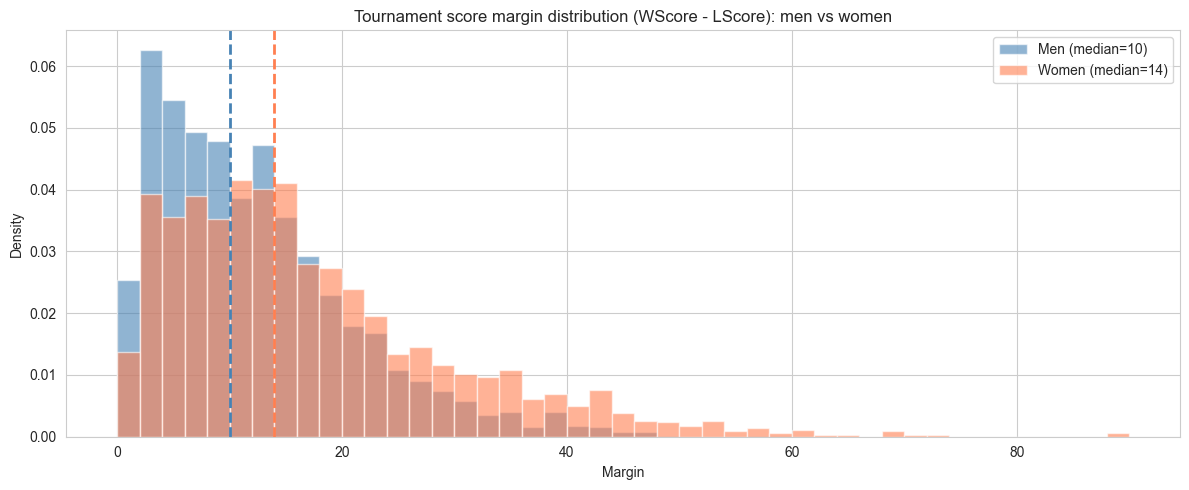

Saved: eda_plots\cell3_margin_hist_overlay.png


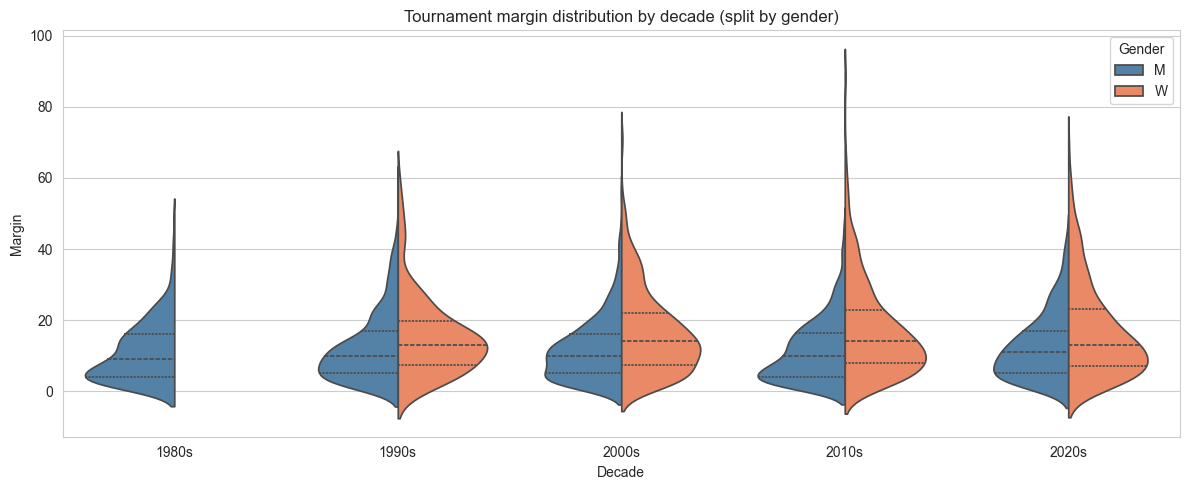

Saved: eda_plots\cell3_margin_by_decade.png


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.paths import get_data_dir

DATA_DIR = Path(get_data_dir())
PLOTS_DIR = Path("eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

def _load_margins(path: Path, sex: str) -> pd.DataFrame:
    df = pd.read_csv(path)[["Season", "WScore", "LScore"]].copy()
    df["Season"] = df["Season"].astype(int)
    df["margin"] = (df["WScore"].astype(int) - df["LScore"].astype(int)).astype(int)
    df["sex"] = sex
    return df[["Season", "margin", "sex"]]

m = _load_margins(DATA_DIR / "MNCAATourneyCompactResults.csv", "M")
w = _load_margins(DATA_DIR / "WNCAATourneyCompactResults.csv", "W")

all_margins = pd.concat([m, w], ignore_index=True)
med = all_margins.groupby("sex")["margin"].median().to_dict()

plt.figure(figsize=(12, 5))
bins = np.arange(0, all_margins["margin"].max() + 2, 2)
plt.hist(m["margin"], bins=bins, alpha=0.6, label=f"Men (median={med['M']:.0f})", color="steelblue", density=True)
plt.hist(w["margin"], bins=bins, alpha=0.6, label=f"Women (median={med['W']:.0f})", color="coral", density=True)
plt.axvline(med["M"], color="steelblue", linestyle="--", linewidth=2)
plt.axvline(med["W"], color="coral", linestyle="--", linewidth=2)
plt.title("Tournament score margin distribution (WScore - LScore): men vs women")
plt.xlabel("Margin")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
out_path = PLOTS_DIR / "cell3_margin_hist_overlay.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

# By decade subplot
def _decade(season: int) -> str:
    d = (season // 10) * 10
    return f"{d}s"

all_margins["decade"] = all_margins["Season"].map(_decade)
decades = sorted(all_margins["decade"].unique())

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
sns.violinplot(
    data=all_margins,
    x="decade",
    y="margin",
    hue="sex",
    split=True,
    inner="quartile",
    palette={"M": "steelblue", "W": "coral"},
    ax=ax,
)
ax.set_title("Tournament margin distribution by decade (split by gender)")
ax.set_xlabel("Decade")
ax.set_ylabel("Margin")
ax.legend(title="Gender")
plt.tight_layout()
out_path = PLOTS_DIR / "cell3_margin_by_decade.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

Computing Elo dictionaries (may take a moment)...


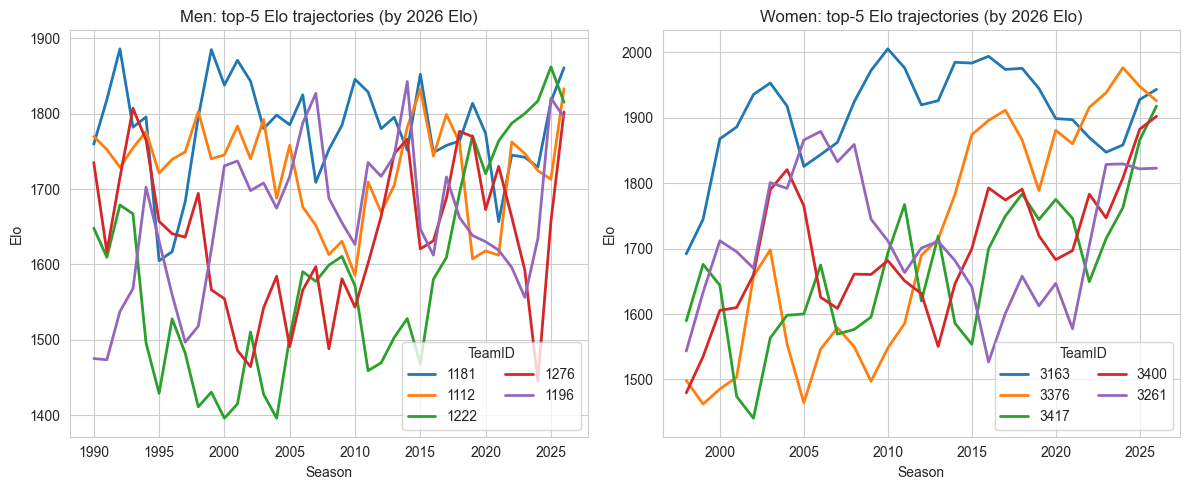

Saved: eda_plots\cell4_top5_elo_trajectories.png


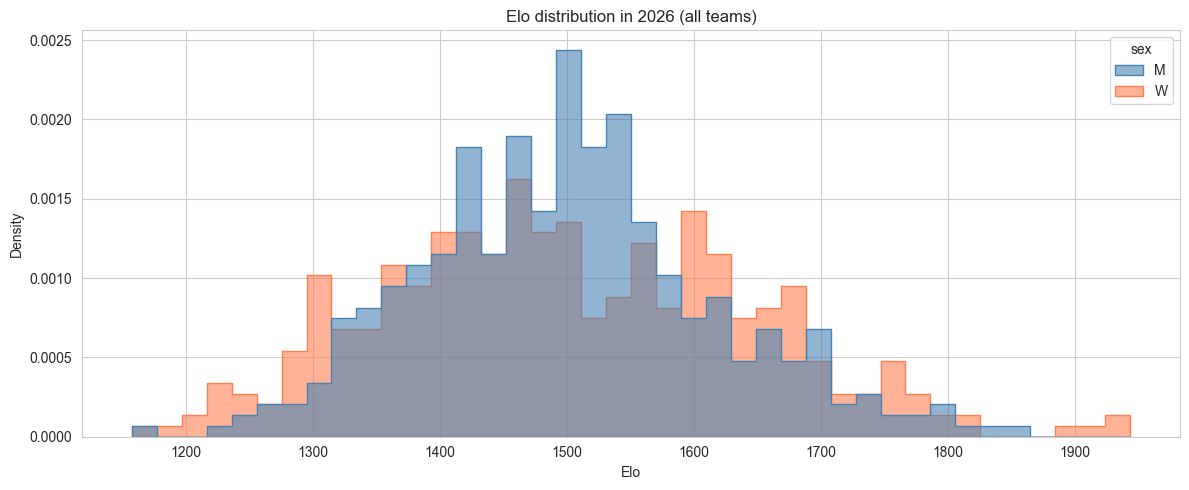

Saved: eda_plots\cell4_elo_hist_2026.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.paths import get_data_dir
from src.elo import compute_elo_men, compute_elo_women

DATA_DIR = str(get_data_dir())
PLOTS_DIR = Path("eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")

print("Computing Elo dictionaries (may take a moment)...")
elo_m = compute_elo_men(DATA_DIR)
elo_w = compute_elo_women(DATA_DIR)

def _elo_df(elo: dict[tuple[int, int], float], sex: str) -> pd.DataFrame:
    rows = [{"Season": s, "TeamID": t, "Elo": r, "sex": sex} for (s, t), r in elo.items()]
    return pd.DataFrame(rows)

dfm = _elo_df(elo_m, "M")
dfw = _elo_df(elo_w, "W")

def _top_teams(df: pd.DataFrame, season: int, n: int = 5) -> list[int]:
    sub = df[df["Season"] == season].sort_values("Elo", ascending=False)
    return sub["TeamID"].head(n).astype(int).tolist()

# Pick top-5 teams by Elo in 2026 for each gender and plot their trajectories since 1990
seasons = np.arange(1990, 2027)

top_m = _top_teams(dfm, 2026, 5)
top_w = _top_teams(dfw, 2026, 5)

def _trajectory(df: pd.DataFrame, team_ids: list[int]) -> pd.DataFrame:
    return df[df["TeamID"].isin(team_ids) & df["Season"].isin(seasons)].copy()

traj_m = _trajectory(dfm, top_m)
traj_w = _trajectory(dfw, top_w)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for tid in top_m:
    s = traj_m[traj_m["TeamID"] == tid].sort_values("Season")
    axes[0].plot(s["Season"], s["Elo"], linewidth=2, label=str(tid))
axes[0].set_title("Men: top-5 Elo trajectories (by 2026 Elo)")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Elo")
axes[0].legend(title="TeamID", ncol=2)

for tid in top_w:
    s = traj_w[traj_w["TeamID"] == tid].sort_values("Season")
    axes[1].plot(s["Season"], s["Elo"], linewidth=2, label=str(tid))
axes[1].set_title("Women: top-5 Elo trajectories (by 2026 Elo)")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Elo")
axes[1].legend(title="TeamID", ncol=2)

plt.tight_layout()
out_path = PLOTS_DIR / "cell4_top5_elo_trajectories.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

# Histogram of all team Elos in 2026
df_2026 = pd.concat([dfm[dfm["Season"] == 2026], dfw[dfw["Season"] == 2026]], ignore_index=True)

plt.figure(figsize=(12, 5))
sns.histplot(data=df_2026, x="Elo", hue="sex", bins=40, alpha=0.6, element="step", stat="density",
             palette={"M": "steelblue", "W": "coral"})
plt.title("Elo distribution in 2026 (all teams)")
plt.xlabel("Elo")
plt.ylabel("Density")
plt.tight_layout()
out_path = PLOTS_DIR / "cell4_elo_hist_2026.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

Pearson r (seed vs Elo) M: -0.6352
Pearson r (seed vs Elo) W: -0.6738


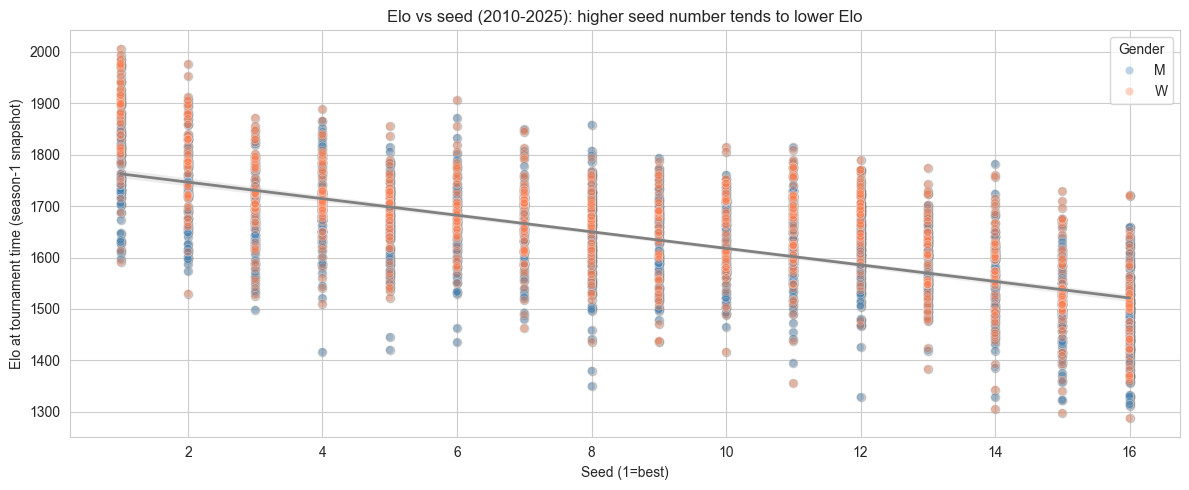

Saved: eda_plots\cell5_elo_vs_seed_scatter.png


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.paths import get_data_dir
from src.elo import compute_elo_men, compute_elo_women

DATA_DIR = Path(get_data_dir())
PLOTS_DIR = Path("eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")

def _seed_num(seed_str: str) -> int | None:
    if not isinstance(seed_str, str):
        return None
    digits = "".join([c for c in seed_str if c.isdigit()])
    if not digits:
        return None
    return int(digits[:2]) if len(digits) >= 2 else int(digits)

def _load_seeds(path: Path, sex: str) -> pd.DataFrame:
    df = pd.read_csv(path)[["Season", "TeamID", "Seed"]].copy()
    df["Season"] = df["Season"].astype(int)
    df["TeamID"] = df["TeamID"].astype(int)
    df["seed"] = df["Seed"].astype(str).map(_seed_num)
    df["sex"] = sex
    return df.dropna(subset=["seed"])[["Season", "TeamID", "seed", "sex"]]

elo_m = compute_elo_men(str(DATA_DIR))
elo_w = compute_elo_women(str(DATA_DIR))

elo_df = pd.concat(
    [
        pd.DataFrame([{"Season": s, "TeamID": t, "Elo": r, "sex": "M"} for (s, t), r in elo_m.items()]),
        pd.DataFrame([{"Season": s, "TeamID": t, "Elo": r, "sex": "W"} for (s, t), r in elo_w.items()]),
    ],
    ignore_index=True,
)

seeds_df = pd.concat(
    [
        _load_seeds(DATA_DIR / "MNCAATourneySeeds.csv", "M"),
        _load_seeds(DATA_DIR / "WNCAATourneySeeds.csv", "W"),
    ],
    ignore_index=True,
)

seasons = np.arange(2010, 2026)
seeds_df = seeds_df[seeds_df["Season"].isin(seasons)].copy()

# Elo at tournament time per prompt: use (season-1) snapshot.
seeds_df["elo_season"] = seeds_df["Season"] - 1
merged = seeds_df.merge(
    elo_df.rename(columns={"Season": "elo_season"}),
    on=["elo_season", "TeamID", "sex"],
    how="left",
)
merged = merged.dropna(subset=["Elo"]).copy()

plt.figure(figsize=(12, 5))
ax = sns.regplot(
    data=merged,
    x="seed",
    y="Elo",
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 2},
    color="gray",
)
sns.scatterplot(
    data=merged,
    x="seed",
    y="Elo",
    hue="sex",
    alpha=0.35,
    palette={"M": "steelblue", "W": "coral"},
    ax=ax,
)
ax.set_title("Elo vs seed (2010-2025): higher seed number tends to lower Elo")
ax.set_xlabel("Seed (1=best)")
ax.set_ylabel("Elo at tournament time (season-1 snapshot)")
ax.legend(title="Gender")

# Pearson r by gender
def _pearson(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])

for sex in ["M", "W"]:
    sub = merged[merged["sex"] == sex]
    r = _pearson(sub["seed"].to_numpy(), sub["Elo"].to_numpy())
    print(f"Pearson r (seed vs Elo) {sex}: {r:.4f}")

plt.tight_layout()
out_path = PLOTS_DIR / "cell5_elo_vs_seed_scatter.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

80% coverage threshold: >= 19/23 seasons. Line drawn after row 17.


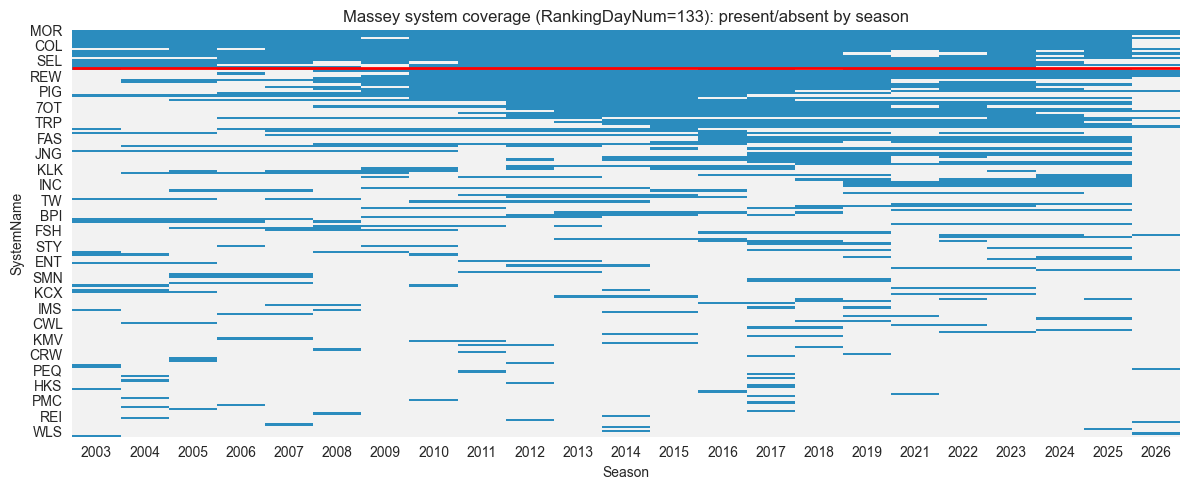

Saved: eda_plots\cell7_massey_coverage_heatmap.png


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.paths import get_data_dir

DATA_DIR = Path(get_data_dir())
PLOTS_DIR = Path("eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")

massey = pd.read_csv(DATA_DIR / "MMasseyOrdinals.csv")[["Season", "SystemName", "RankingDayNum"]].copy()
massey["Season"] = massey["Season"].astype(int)
massey["SystemName"] = massey["SystemName"].astype(str)

# Prompt: use RankingDayNum=133 for stable coverage reporting.
massey = massey[massey["RankingDayNum"] == 133].copy()

seasons = np.sort(massey["Season"].unique())
systems = (
    massey.groupby("SystemName", as_index=False)
    .agg(n_seasons=("Season", "nunique"))
    .sort_values("n_seasons", ascending=False)
)
systems_list = systems["SystemName"].tolist()

present = (
    massey.drop_duplicates(["SystemName", "Season"])
    .assign(present=1)
    .pivot(index="SystemName", columns="Season", values="present")
    .reindex(index=systems_list, columns=seasons)
    .fillna(0)
    .astype(int)
)

total_seasons = int(len(seasons))
min_coverage = 0.8
threshold = int(np.ceil(min_coverage * total_seasons))
meets = systems["n_seasons"] >= threshold
last_idx = int(np.where(meets.to_numpy())[0].max()) if meets.any() else -1

plt.figure(figsize=(12, 5))
ax = sns.heatmap(present, cmap=sns.color_palette(["#f2f2f2", "#2b8cbe"]), cbar=False)
ax.set_title("Massey system coverage (RankingDayNum=133): present/absent by season")
ax.set_xlabel("Season")
ax.set_ylabel("SystemName")
if last_idx >= 0:
    ax.hlines(last_idx + 1, *ax.get_xlim(), colors="red", linewidth=2)
    print(f"80% coverage threshold: >= {threshold}/{total_seasons} seasons. Line drawn after row {last_idx+1}.")
else:
    print(f"No systems meet 80% coverage threshold ({threshold}/{total_seasons}).")

plt.tight_layout()
out_path = PLOTS_DIR / "cell7_massey_coverage_heatmap.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PLOTS_DIR = Path("eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")

print("CELL 8 — Feature importance (gain-based)")

try:
    # Expect model_men from training notebook (Prompt 08 / model.ipynb).
    model = model_men  # noqa: F821
    feature_names = list(X_train_men[[c for c in X_train_men.columns if c != "Season"]].columns)  # noqa: F821

    booster = model.get_booster()
    score = booster.get_score(importance_type="gain")

    imp = pd.DataFrame(
        {"feature": list(score.keys()), "gain": list(score.values())}
    ).sort_values("gain", ascending=False)

    # Map XGBoost f0.. to real names if needed
    if imp["feature"].str.match(r"^f\d+$").all():
        imp["idx"] = imp["feature"].str.replace("f", "", regex=False).astype(int)
        imp["feature"] = imp["idx"].map(lambda i: feature_names[i] if i < len(feature_names) else f"f{i}")
        imp = imp.drop(columns=["idx"])

    plt.figure(figsize=(12, 5))
    sns.barplot(data=imp.head(25), y="feature", x="gain", color="steelblue")
    plt.title("XGBoost feature importance (gain) — top 25")
    plt.xlabel("Gain")
    plt.ylabel("Feature")
    plt.tight_layout()
    out_path = PLOTS_DIR / "cell8_xgb_feature_importance.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path)

except Exception as e:
    print("Skipping CELL 8 (model not found / not trained yet). Reason:", repr(e))

CELL 8 — Feature importance (gain-based)
Skipping CELL 8 (model not found / not trained yet). Reason: NameError("name 'model_men' is not defined")


CELL 9 — Calibration reliability diagram
In-memory calibration arrays not found; rebuilding from saved tuned artifacts...


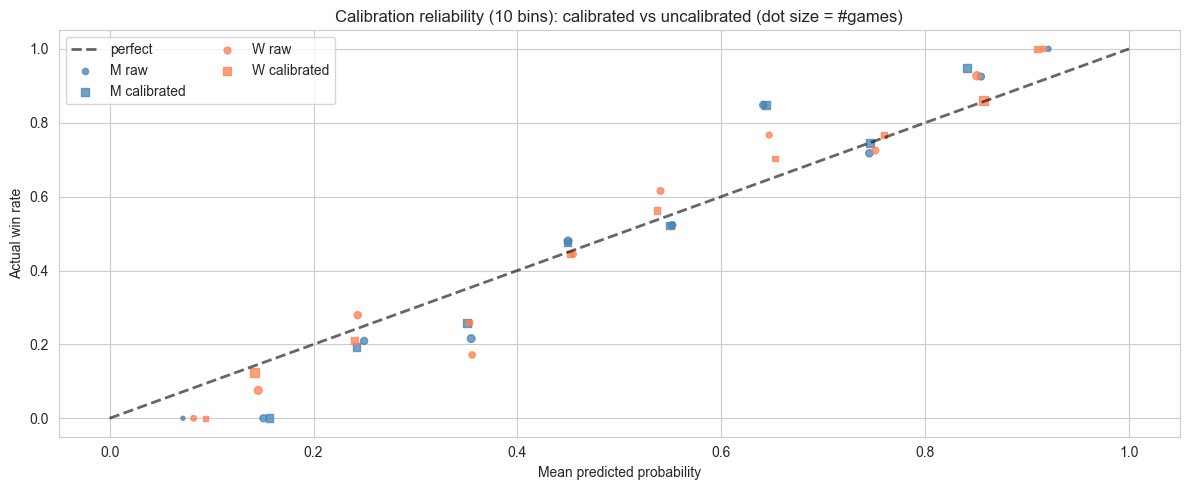

Saved: eda_plots\cell9_calibration_reliability.png
Men Brier raw -> calibrated: 0.154680073261261 -> 0.15652593088425454
Women Brier raw -> calibrated: 0.14209270477294922 -> 0.14055779921856687
Women extreme check (raw > 0.90): n= 28 raw_mean= 0.916439414024353 cal_mean= 0.9121888238398389 actual_win_rate= 1.0


In [9]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from sklearn.metrics import brier_score_loss

# Ensure src import works from notebook cwd
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.features import encode_matchups_symmetric
from src.paths import get_data_dir

PLOTS_DIR = Path("eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path(get_data_dir())

print("CELL 9 — Calibration reliability diagram")

# Prefer in-memory variables from model notebook if present.
have_in_memory = all(
    name in globals()
    for name in ["raw_men", "probs_men_cal", "y_cal_men", "raw_women", "probs_women_cal", "y_cal_women"]
)

if have_in_memory:
    raw_m = np.asarray(raw_men)
    cal_m = np.asarray(probs_men_cal)
    y_m = np.asarray(y_cal_men).astype(int)

    raw_w = np.asarray(raw_women)
    cal_w = np.asarray(probs_women_cal)
    y_w = np.asarray(y_cal_women).astype(int)
    print("Using in-memory calibration arrays from model notebook.")
else:
    print("In-memory calibration arrays not found; rebuilding from saved tuned artifacts...")

    # Build minimal feature_store if not present.
    if "feature_store" not in globals():
        from src.features import compute_efficiency, compute_four_factors
        from src.massey import load_massey_features
        from src.elo import compute_elo_men, compute_elo_women

        elo_m = compute_elo_men(str(DATA_DIR))
        elo_w = compute_elo_women(str(DATA_DIR))
        elo_all = dict(elo_m)
        elo_all.update(elo_w)

        m_det = pd.read_csv(DATA_DIR / "MRegularSeasonDetailedResults.csv")
        w_det = pd.read_csv(DATA_DIR / "WRegularSeasonDetailedResults.csv")
        efficiency = pd.concat([compute_efficiency(m_det), compute_efficiency(w_det)], ignore_index=True)
        four_factors = pd.concat([compute_four_factors(m_det), compute_four_factors(w_det)], ignore_index=True)
        massey = load_massey_features(str(DATA_DIR), min_coverage=0.8)

        def _seed_num(seed_str: str) -> int | None:
            if not isinstance(seed_str, str):
                return None
            digits = "".join([c for c in seed_str if c.isdigit()])
            if not digits:
                return None
            return int(digits[:2]) if len(digits) >= 2 else int(digits)

        seeds_m_raw = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")[["Season", "TeamID", "Seed"]].copy()
        seeds_w_raw = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")[["Season", "TeamID", "Seed"]].copy()
        seeds_m = seeds_m_raw.assign(Season=seeds_m_raw["Season"].astype(int), TeamID=seeds_m_raw["TeamID"].astype(int), Seed=seeds_m_raw["Seed"].astype(str).map(_seed_num)).dropna(subset=["Seed"])
        seeds_w = seeds_w_raw.assign(Season=seeds_w_raw["Season"].astype(int), TeamID=seeds_w_raw["TeamID"].astype(int), Seed=seeds_w_raw["Seed"].astype(str).map(_seed_num)).dropna(subset=["Seed"])

        feature_store = {
            "elo": elo_all,
            "efficiency": efficiency,
            "four_factors": four_factors,
            "massey": massey,
            "seeds_m": seeds_m[["Season", "TeamID", "Seed"]].copy(),
            "seeds_w": seeds_w[["Season", "TeamID", "Seed"]].copy(),
        }

    # Load tuned model + calibrator artifacts
    model_m_path = Path("models") / "best_men.pkl"
    model_w_path = Path("models") / "best_women.pkl"
    cal_m_path = Path("models") / "best_calibrator_men.joblib"
    cal_w_path = Path("models") / "best_calibrator_women.joblib"

    if not model_m_path.exists() or not model_w_path.exists() or not cal_m_path.exists() or not cal_w_path.exists():
        raise RuntimeError(
            "Missing tuned model/calibrator artifacts. Expected: "
            f"{model_m_path}, {model_w_path}, {cal_m_path}, {cal_w_path}. "
            "Run hypetyune notebook first."
        )

    model_m = load(model_m_path)
    model_w = load(model_w_path)
    cal_m_obj = load(cal_m_path)
    cal_w_obj = load(cal_w_path)

    # Build 2019-2022 calibration sets (same scheme used in training notebooks)
    cal_seasons = np.array([2019, 2020, 2021, 2022])

    def _build_xy(tourney_df: pd.DataFrame, seeds_df: pd.DataFrame):
        d = tourney_df[tourney_df["Season"].astype(int).isin(cal_seasons)].copy()
        season = d["Season"].astype(int).to_numpy()
        w_team = d["WTeamID"].astype(int).to_numpy()
        l_team = d["LTeamID"].astype(int).to_numpy()

        team1 = np.minimum(w_team, l_team)
        team2 = np.maximum(w_team, l_team)
        y = (w_team == team1).astype(int)

        matchups = pd.DataFrame({"Season": season, "Team1ID": team1, "Team2ID": team2})
        enc = encode_matchups_symmetric(
            matchups_df=matchups,
            elo_dict=feature_store["elo"],
            efficiency_df=feature_store["efficiency"],
            four_factors_df=feature_store["four_factors"],
            massey_df=feature_store["massey"],
            seeds_df=seeds_df,
            label_col=pd.Series(y, name="label"),
        )
        X = enc.drop(columns=["label"]).copy()
        y_out = enc["label"].astype(int).to_numpy()
        return X, y_out

    mn_compact = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
    wn_compact = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")

    X_m, y_m = _build_xy(mn_compact, feature_store["seeds_m"])
    X_w, y_w = _build_xy(wn_compact, feature_store["seeds_w"])

    raw_m = model_m.predict_proba(X_m)[:, 1]
    raw_w = model_w.predict_proba(X_w)[:, 1]
    cal_m = cal_m_obj.transform_men(raw_m)
    cal_w = cal_w_obj.transform_women(raw_w)


def reliability_points(y: np.ndarray, p: np.ndarray, bins: int = 10) -> pd.DataFrame:
    edges = np.linspace(0.0, 1.0, bins + 1)
    idx = np.digitize(p, edges, right=False) - 1
    rows = []
    for b in range(bins):
        mask = idx == b
        if not np.any(mask):
            continue
        rows.append({"bin": b, "p_mean": float(np.mean(p[mask])), "y_rate": float(np.mean(y[mask])), "n": int(mask.sum())})
    return pd.DataFrame(rows)

m_raw = reliability_points(y_m, raw_m, 10).assign(sex="M", kind="raw")
m_cal = reliability_points(y_m, cal_m, 10).assign(sex="M", kind="calibrated")
w_raw = reliability_points(y_w, raw_w, 10).assign(sex="W", kind="raw")
w_cal = reliability_points(y_w, cal_w, 10).assign(sex="W", kind="calibrated")

df = pd.concat([m_raw, m_cal, w_raw, w_cal], ignore_index=True)

plt.figure(figsize=(12, 5))
plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=2, alpha=0.6, label="perfect")

def _plot(sex: str, kind: str, color: str, marker: str):
    sub = df[(df["sex"] == sex) & (df["kind"] == kind)].copy()
    plt.scatter(sub["p_mean"], sub["y_rate"], s=sub["n"] * 0.6, alpha=0.75, color=color, marker=marker, label=f"{sex} {kind}")

_plot("M", "raw", "steelblue", "o")
_plot("M", "calibrated", "steelblue", "s")
_plot("W", "raw", "coral", "o")
_plot("W", "calibrated", "coral", "s")

plt.title("Calibration reliability (10 bins): calibrated vs uncalibrated (dot size = #games)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual win rate")
plt.legend(ncol=2)
plt.tight_layout()
out_path = PLOTS_DIR / "cell9_calibration_reliability.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", out_path)

print("Men Brier raw -> calibrated:", float(brier_score_loss(y_m, raw_m)), "->", float(brier_score_loss(y_m, cal_m)))
print("Women Brier raw -> calibrated:", float(brier_score_loss(y_w, raw_w)), "->", float(brier_score_loss(y_w, cal_w)))

# Verify calibration behavior on women's extreme high-probability predictions.
extreme_mask = raw_w > 0.90
if int(extreme_mask.sum()) == 0:
    print("Women extreme check (raw > 0.90): no samples in calibration window.")
else:
    print(
        "Women extreme check (raw > 0.90): n=",
        int(extreme_mask.sum()),
        "raw_mean=",
        float(np.mean(raw_w[extreme_mask])),
        "cal_mean=",
        float(np.mean(cal_w[extreme_mask])),
        "actual_win_rate=",
        float(np.mean(y_w[extreme_mask])),
    )